In [2]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


pd.options.display.max_columns = 500

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA

# Кластеризация

Наша задача - предсказать есть диабет у индивида или нет. В качестве таргета - колонка Diabetes. В нем три различных значения: `0`, `1`, `2`. `0` означает, что наблюдаемой здоров, `1` значит, что есть риск диабета, `2` означает наличие диабета. В качестве признаков будем использовать пол, количество лет в США, доход семьи и некоторые показатели, измеренные медицинскими работниками.  

**Задание 1.** В этой части ДЗ попробуем использовать кластеризацию как инструмент при проведении моделирования в задаче классификации

In [3]:
df = pd.read_csv('datahw21.csv', index_col='Unnamed: 0')

df.head()

,Gender,Years_in_US,Family_income,ArmCircum,SaggitalAbdominal,GripStrength,Breast_fed,Diabetes
0,1,0.0,0.84,35.3,20.6,55.2,2.0,2.0
1,1,0.0,1.78,34.7,24.4,61.5,2.0,2.0
2,1,0.0,4.51,33.5,25.6,91.0,2.0,2.0
3,1,0.0,2.52,21.0,14.9,32.2,2.0,0.0
4,2,0.0,5.00,25.2,20.7,30.9,2.0,0.0


(array([0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5]),
 [Text(0.5, 0, 'Gender'),
  Text(1.5, 0, 'Years_in_US'),
  Text(2.5, 0, 'Family_income'),
  Text(3.5, 0, 'ArmCircum'),
  Text(4.5, 0, 'SaggitalAbdominal'),
  Text(5.5, 0, 'GripStrength'),
  Text(6.5, 0, 'Breast_fed'),
  Text(7.5, 0, 'Diabetes')])

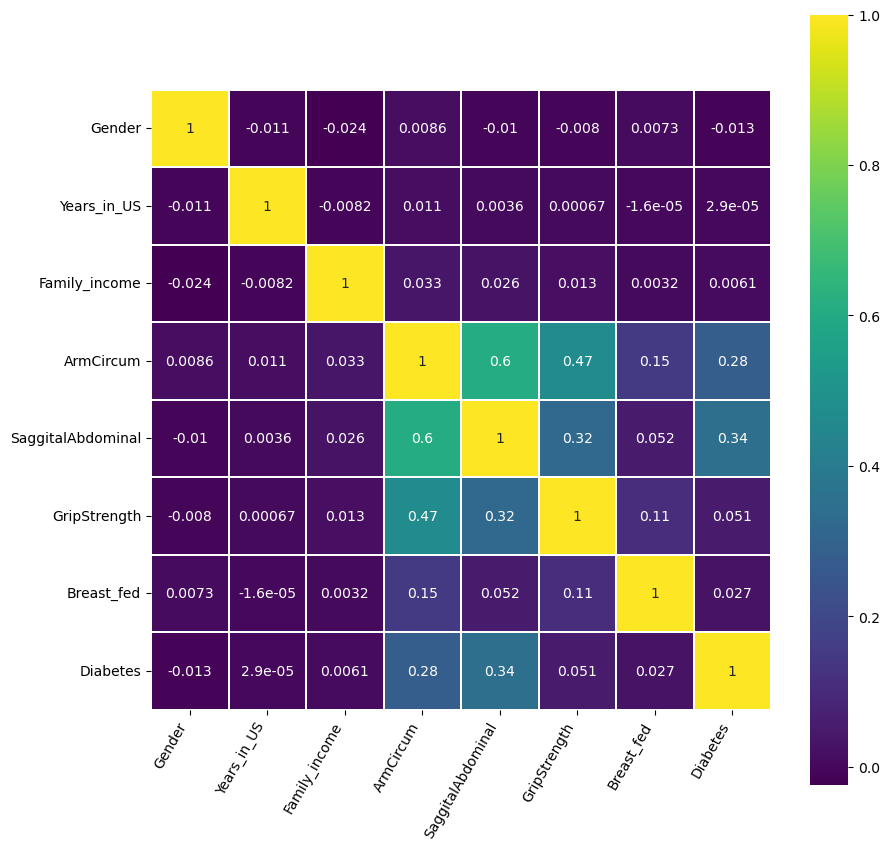

In [8]:
### Посмотрим как устроены данные
### Изобразим корреляционную матрицу

colormap = plt.cm.viridis
plt.figure(figsize=(10,10))
sns.heatmap(df.corr(), linewidths=0.1, vmax=1.0, square=True, cmap=colormap, annot=True)
plt.xticks(rotation=60, ha='right')

In [25]:
### Разделим выборку на трейн-тест

data = df.drop(['Diabetes'], axis=1)
target = df[['Diabetes']]

X_train, X_test, y_train, y_test = train_test_split(data,
                                                    target, 
                                                    test_size=0.25,
                                                    random_state=1)

Для того, чтобы использовать K-means, лучше будет отнормировать данные. 

In [26]:
### Воспользуемся StandardScaler

### Your code is here
scaler = StandardScaler()
scaler.fit(X_train)



,copy,True
,with_mean,True
,with_std,True


In [27]:
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

Обучим K-Means с параметрами `n_clusters` = 3, `tol` = 0.0005. Выбор параметров обусловлен тем, что у нас три возможных значения таргета. Но в целом основной подход подбора количества кластеров - по кривой зависимости внутрикластерного и межкластерного расстояний от количества кластеров.

Установите `random_state` = 1

In [31]:
### Your code is here
kmeans = KMeans(n_clusters=3, tol=0.0005, random_state=1)
kmeans.fit(X_train)


,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0005
,verbose,0
,random_state,1
,copy_x,True
,algorithm,'lloyd'


Посчитаем качество на изначальных данных(нормированных). Для этого обучите с дефолтными параметрами `RandomForestClassifier`, `LogisticRegression`, `LinearSVC`. Там, где нужно, установите `random_state` = 1. (1б)

In [29]:
### Your code is here
models = [RandomForestClassifier(random_state=1), LogisticRegression(random_state=1), LinearSVC(random_state=1)]
for model in models:
    model.fit(X_train, y_train)
    acc_score = accuracy_score(y_test, model.predict(X_test))
    print(f'Accuracy score for {model} = {acc_score:.3f}')



Accuracy score for RandomForestClassifier(random_state=1) = 0.886
Accuracy score for LogisticRegression(random_state=1) = 0.888
Accuracy score for LinearSVC(random_state=1) = 0.892


Добавьте в признаковое описание номер кластера и посчитайте качество с новым признаком! Стало ли качество хоть сколько-то лучше? (1б)

In [33]:
### Your code is here
X_train_with_cluster = X_train.copy()
X_test_with_cluster = X_test.copy()

train_clusters = kmeans.predict(X_train)
test_clusters = kmeans.predict(X_test)

X_train_with_cluster = np.column_stack([X_train, train_clusters])
X_test_with_cluster = np.column_stack([X_test, test_clusters])

models = [RandomForestClassifier(random_state=1), LogisticRegression(random_state=1), LinearSVC(random_state=1)]
for model in models:
    model.fit(X_train_with_cluster, y_train)
    acc_score = accuracy_score(y_test, model.predict(X_test_with_cluster))
    print(f'Accuracy score for {model} = {acc_score:.3f}')


Accuracy score for RandomForestClassifier(random_state=1) = 0.888
Accuracy score for LogisticRegression(random_state=1) = 0.888
Accuracy score for LinearSVC(random_state=1) = 0.893


Посчитаем расстояния от объектов до центров кластеров. Для этого воспользуемся методом `transform` обученного класса kmeans.

Обучим и посчитаем метрики исключительно на расстояниях до центра. Убедимся, что такой подход имеет право на существование, если данные позволяют, то качество не сильно должно пострадать. А в каких-то случаях может оказаться даже лучше! Таким образом можно снижать размерность данных. (2б)

In [34]:
### Your code is here
center_train = kmeans.transform(X_train)
center_test = kmeans.transform(X_test)

models = [RandomForestClassifier(random_state=1), LogisticRegression(random_state=1), LinearSVC(random_state=1)]
for model in models:
    model.fit(center_train, y_train)
    acc_score = accuracy_score(y_test, model.predict(center_test))
    print(f'Accuracy score for {model} = {acc_score:.3f}')


Accuracy score for RandomForestClassifier(random_state=1) = 0.883
Accuracy score for LogisticRegression(random_state=1) = 0.892
Accuracy score for LinearSVC(random_state=1) = 0.892


In [36]:
df['Diabetes'].unique()


array([2., 0., 1.])

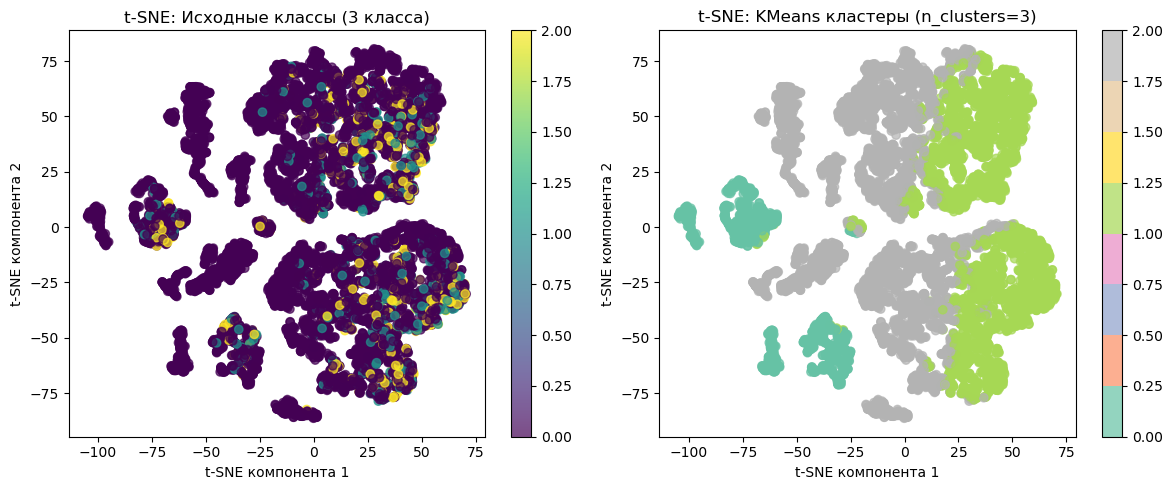

Adjusted Rand Index: 0.035
Normalized Mutual Info: 0.044
(Чем ближе к 1, тем лучше соответствие кластеров и классов)


In [37]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Масштабируем данные
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data)

# t-SNE для 2D визуализации
tsne = TSNE(n_components=2, random_state=1, perplexity=30)
X_tsne = tsne.fit_transform(X_scaled)

# Визуализация с истинными классами
plt.figure(figsize=(12, 5))

# Подграфик 1: Исходные классы
plt.subplot(1, 2, 1)
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=target['Diabetes'], 
                     cmap='viridis', alpha=0.7)
plt.colorbar(scatter)
plt.title('t-SNE: Исходные классы (3 класса)')
plt.xlabel('t-SNE компонента 1')
plt.ylabel('t-SNE компонента 2')

# Подграфик 2: KMeans кластеры
kmeans = KMeans(n_clusters=3, random_state=1)
kmeans_labels = kmeans.fit_predict(X_scaled)

plt.subplot(1, 2, 2)
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=kmeans_labels, 
                     cmap='Set2', alpha=0.7)
plt.colorbar(scatter)
plt.title('t-SNE: KMeans кластеры (n_clusters=3)')
plt.xlabel('t-SNE компонента 1')
plt.ylabel('t-SNE компонента 2')

plt.tight_layout()
plt.show()

# Оценка соответствия кластеров и классов
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

ari_score = adjusted_rand_score(target['Diabetes'], kmeans_labels)
nmi_score = normalized_mutual_info_score(target['Diabetes'], kmeans_labels)

print(f"Adjusted Rand Index: {ari_score:.3f}")
print(f"Normalized Mutual Info: {nmi_score:.3f}")
print("(Чем ближе к 1, тем лучше соответствие кластеров и классов)")

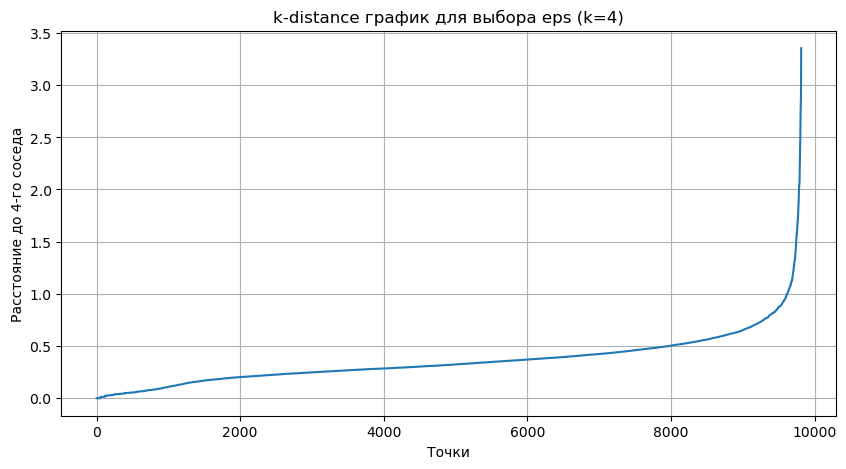

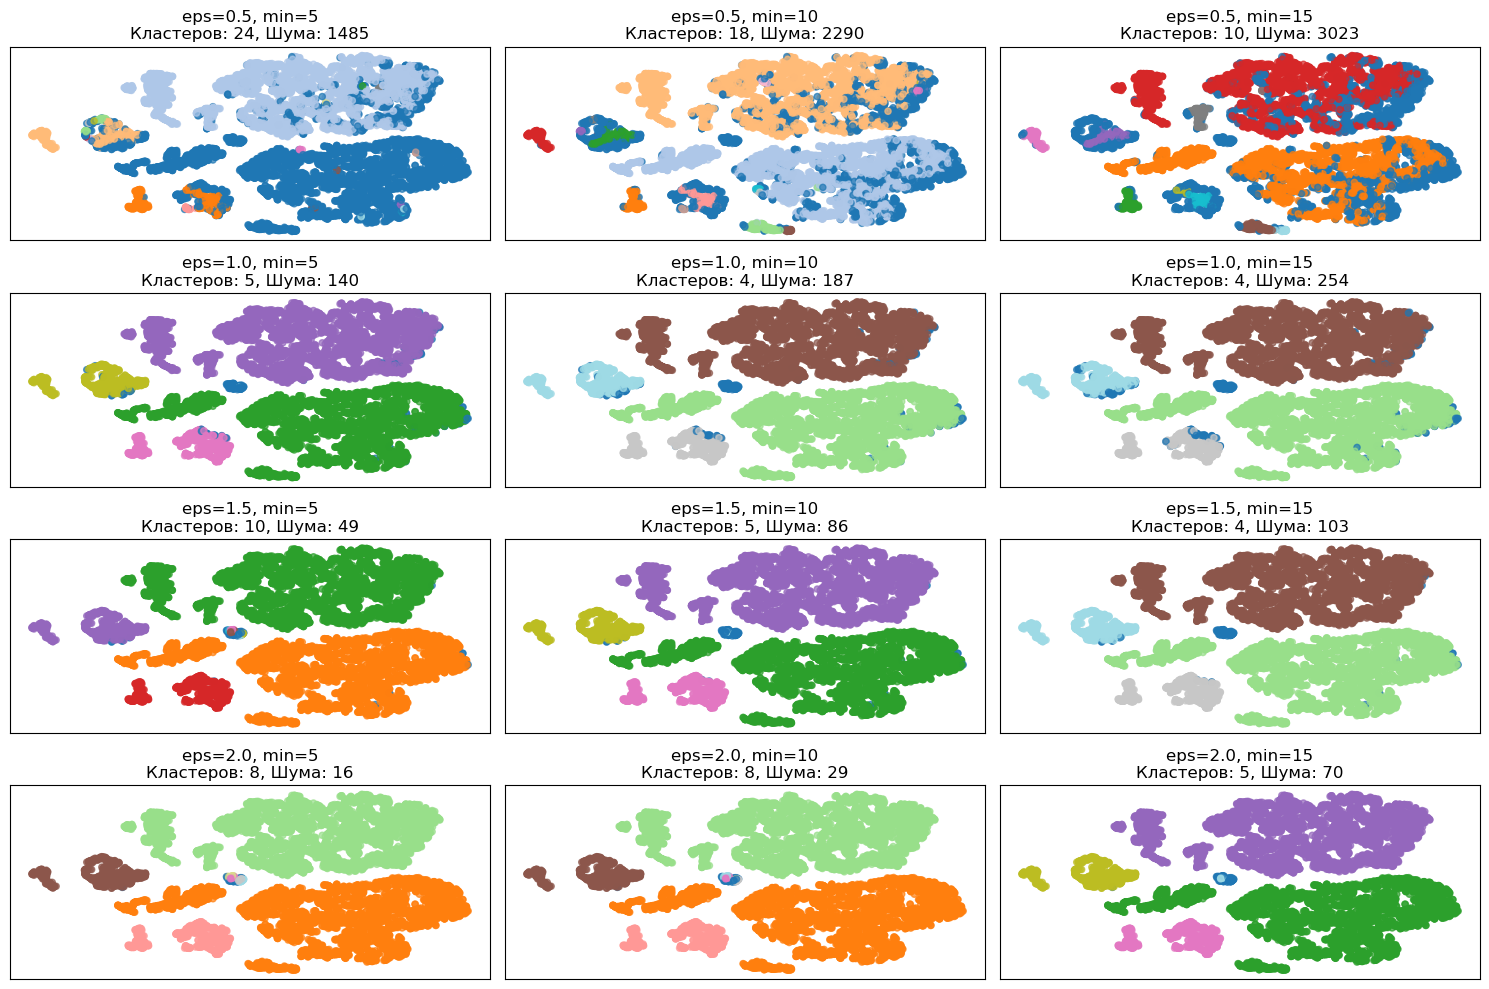

DBSCAN результаты:
  Найдено кластеров: 4
  Точек шума: 187 (1.9%)


In [38]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
import numpy as np

# Оптимальный eps через анализ k-расстояний
neighbors = NearestNeighbors(n_neighbors=4)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

# Сортируем расстояния
distances = np.sort(distances[:, 3], axis=0)

plt.figure(figsize=(10, 5))
plt.plot(distances)
plt.title('k-distance график для выбора eps (k=4)')
plt.xlabel('Точки')
plt.ylabel('Расстояние до 4-го соседа')
plt.grid(True)
plt.show()

# Попробуем разные параметры DBSCAN
eps_values = [0.5, 1.0, 1.5, 2.0]
min_samples_values = [5, 10, 15]

plt.figure(figsize=(15, 10))

for i, eps in enumerate(eps_values, 1):
    for j, min_samples in enumerate(min_samples_values, 1):
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        dbscan_labels = dbscan.fit_predict(X_scaled)
        
        plt.subplot(len(eps_values), len(min_samples_values), (i-1)*len(min_samples_values) + j)
        scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=dbscan_labels, 
                            cmap='tab20', alpha=0.7, s=20)
        
        n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
        n_noise = list(dbscan_labels).count(-1)
        
        plt.title(f'eps={eps}, min={min_samples}\nКластеров: {n_clusters}, Шума: {n_noise}')
        plt.xticks([])
        plt.yticks([])

plt.tight_layout()
plt.show()

# Лучший DBSCAN (подберите параметры по графику)
dbscan_best = DBSCAN(eps=1.0, min_samples=10)
dbscan_labels = dbscan_best.fit_predict(X_scaled)

print(f"DBSCAN результаты:")
print(f"  Найдено кластеров: {len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)}")
print(f"  Точек шума: {list(dbscan_labels).count(-1)} ({list(dbscan_labels).count(-1)/len(dbscan_labels)*100:.1f}%)")

Сравнение методов кластеризации:
           Method  Clusters  Silhouette  Calinski-Harabasz
       KMeans (3)         3    0.234974        2265.524247
       KMeans (5)         5    0.234714        2679.026312
           DBSCAN         5    0.221996        1334.303425
Agglomerative (3)         3    0.301134        1895.044205
Agglomerative (5)         5    0.187602        2218.889531


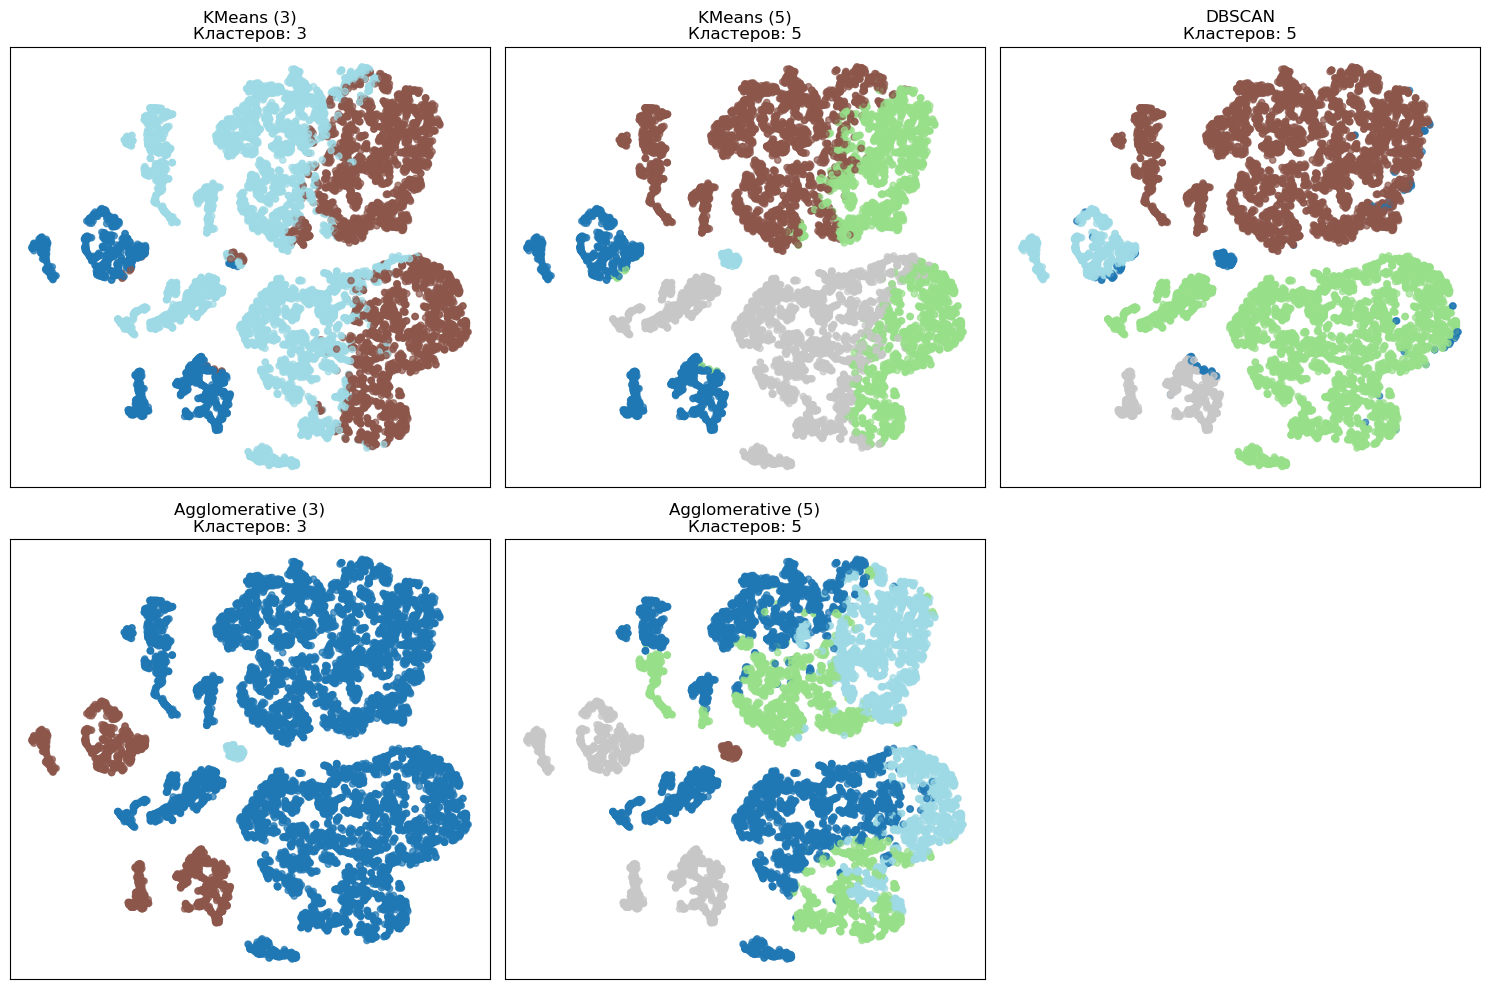

In [39]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score

# Разные методы кластеризации
clustering_methods = {
    'KMeans (3)': KMeans(n_clusters=3, random_state=1),
    'KMeans (5)': KMeans(n_clusters=5, random_state=1),
    'DBSCAN': DBSCAN(eps=1.0, min_samples=10),
    'Agglomerative (3)': AgglomerativeClustering(n_clusters=3),
    'Agglomerative (5)': AgglomerativeClustering(n_clusters=5)
}

# Оценка качества кластеризации
results = []
labels_dict = {}

for name, model in clustering_methods.items():
    labels = model.fit_predict(X_scaled)
    labels_dict[name] = labels
    
    if len(set(labels)) > 1:  # Для метрик нужно хотя бы 2 кластера
        silhouette = silhouette_score(X_scaled, labels)
        calinski = calinski_harabasz_score(X_scaled, labels)
    else:
        silhouette = calinski = 0
    
    results.append({
        'Method': name,
        'Clusters': len(set(labels)),
        'Silhouette': silhouette,
        'Calinski-Harabasz': calinski
    })

# Таблица результатов
results_df = pd.DataFrame(results)
print("Сравнение методов кластеризации:")
print(results_df.to_string(index=False))

# Визуализация всех методов
plt.figure(figsize=(15, 10))

for idx, (name, labels) in enumerate(labels_dict.items(), 1):
    plt.subplot(2, 3, idx)
    scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels, 
                         cmap='tab20', alpha=0.7, s=20)
    plt.title(f'{name}\nКластеров: {len(set(labels))}')
    plt.xticks([])
    plt.yticks([])

plt.tight_layout()
plt.show()

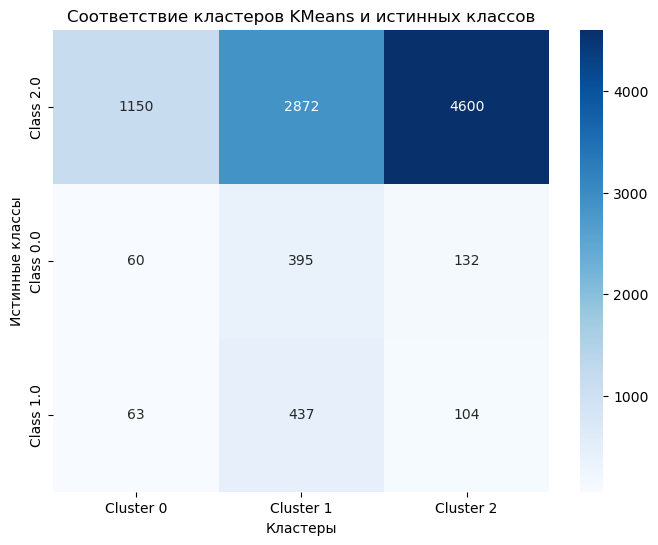

Кластер 0: 1273 точек, чаще всего класс 0.0
Кластер 1: 3704 точек, чаще всего класс 0.0
Кластер 2: 4836 точек, чаще всего класс 0.0

Точность соответствия кластеров классам: 0.879 (8622/9813)


In [40]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# KMeans с 3 кластерами (как у вас в таргете)
kmeans = KMeans(n_clusters=3, random_state=1)
kmeans_labels = kmeans.fit_predict(X_scaled)

# Матрица сопряженности
cm = confusion_matrix(target['Diabetes'], kmeans_labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=[f'Cluster {i}' for i in range(3)],
            yticklabels=[f'Class {i}' for i in target['Diabetes'].unique()])
plt.title('Соответствие кластеров KMeans и истинных классов')
plt.ylabel('Истинные классы')
plt.xlabel('Кластеры')
plt.show()

# Какой кластер соответствует какому классу
cluster_to_class = {}
for cluster in range(3):
    # Находим самый частый класс в кластере
    mask = kmeans_labels == cluster
    if sum(mask) > 0:
        most_common_class = target['Diabetes'][mask].mode()[0]
        cluster_to_class[cluster] = most_common_class
        print(f"Кластер {cluster}: {sum(mask)} точек, чаще всего класс {most_common_class}")

# Точность "классификации" кластерами
correct = 0
total = 0
for idx, (true_class, cluster) in enumerate(zip(target['Diabetes'], kmeans_labels)):
    if cluster in cluster_to_class:
        if true_class == cluster_to_class[cluster]:
            correct += 1
        total += 1

if total > 0:
    print(f"\nТочность соответствия кластеров классам: {correct/total:.3f} ({correct}/{total})")

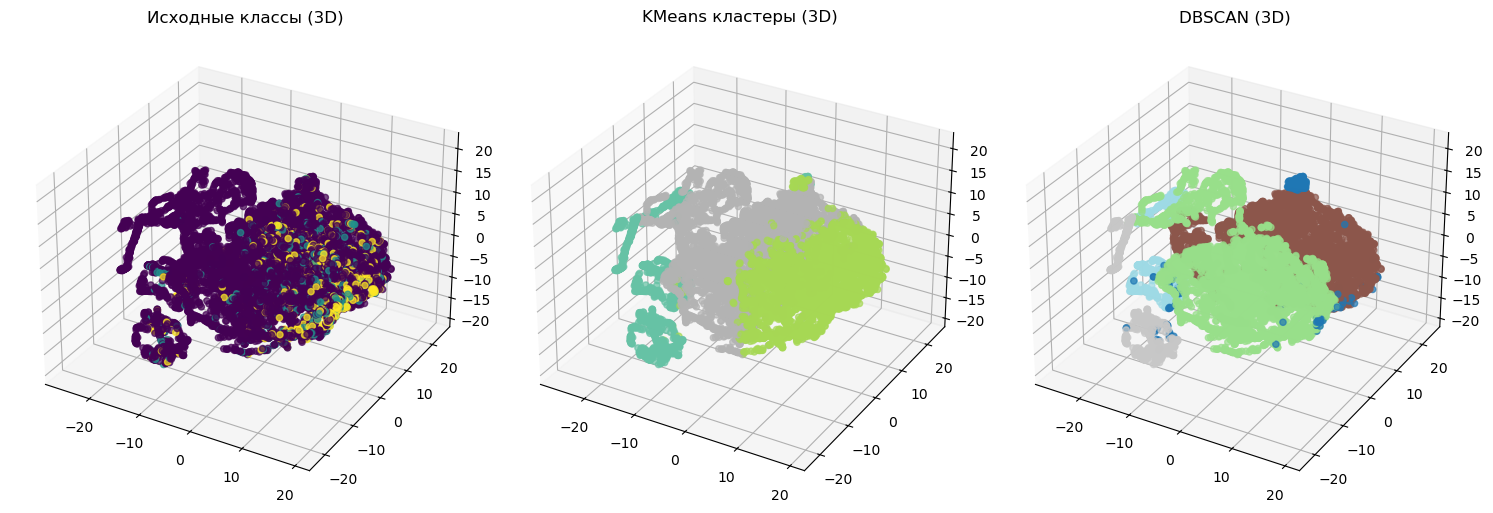

In [41]:
from mpl_toolkits.mplot3d import Axes3D

# t-SNE в 3D
tsne_3d = TSNE(n_components=3, random_state=1)
X_tsne_3d = tsne_3d.fit_transform(X_scaled)

fig = plt.figure(figsize=(15, 5))

# Исходные классы
ax1 = fig.add_subplot(131, projection='3d')
scatter1 = ax1.scatter(X_tsne_3d[:, 0], X_tsne_3d[:, 1], X_tsne_3d[:, 2], 
                      c=target['Diabetes'], cmap='viridis', alpha=0.7)
ax1.set_title('Исходные классы (3D)')

# KMeans кластеры
ax2 = fig.add_subplot(132, projection='3d')
scatter2 = ax2.scatter(X_tsne_3d[:, 0], X_tsne_3d[:, 1], X_tsne_3d[:, 2], 
                      c=kmeans_labels, cmap='Set2', alpha=0.7)
ax2.set_title('KMeans кластеры (3D)')

# DBSCAN
ax3 = fig.add_subplot(133, projection='3d')
scatter3 = ax3.scatter(X_tsne_3d[:, 0], X_tsne_3d[:, 1], X_tsne_3d[:, 2], 
                      c=dbscan_labels, cmap='tab20', alpha=0.7)
ax3.set_title('DBSCAN (3D)')

plt.tight_layout()
plt.show()